In [1]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import AveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import cv2

In [2]:
INIT_LR = 1e-4
EPOCHS = 10
BS = 32
DATASET_PATH = "dataset"

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

In [4]:
train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=BS,
    class_mode="binary",
    subset="training"
)

Found 15477 images belonging to 2 classes.


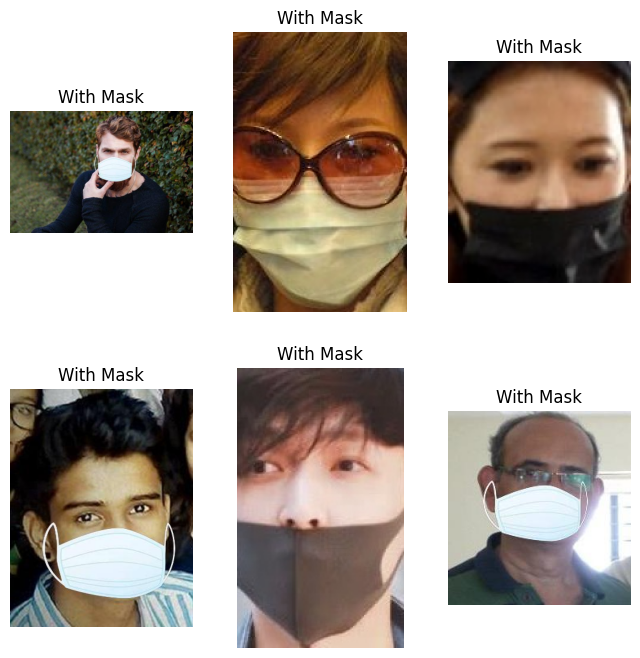

In [5]:
images = os.listdir("dataset/with_mask")

plt.figure(figsize=(8,8))

for i in range(6):
    img_path = os.path.join("dataset/with_mask", images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("With Mask")
    plt.axis("off")

plt.show()

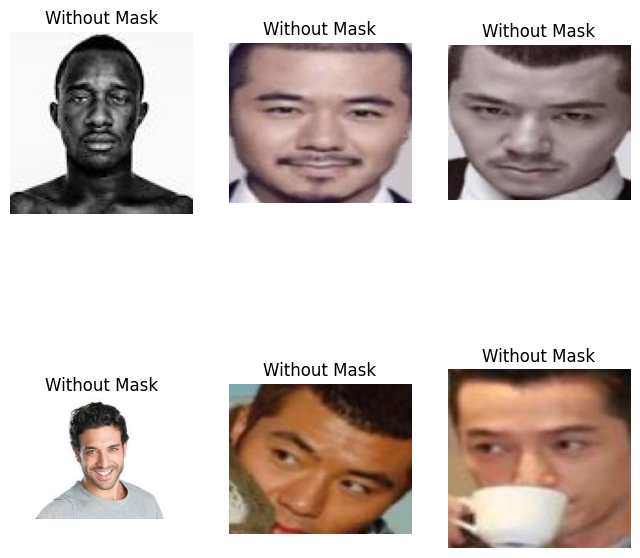

In [6]:
dataset_path = "dataset/without_mask"

images = os.listdir(dataset_path)

plt.figure(figsize=(8,8))

for i in range(6):
    img_path = os.path.join(dataset_path, images[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title("Without Mask")
    plt.axis("off")

plt.show()

In [7]:
val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224, 224),
    batch_size=BS,
    class_mode="binary",
    subset="validation"
)

Found 3868 images belonging to 2 classes.


In [8]:
print("class indices", train_gen.class_indices)
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

class indices {'with_mask': 0, 'without_mask': 1}


Custom Head


In [9]:
headModel=base_model.output
headModel=AveragePooling2D(pool_size=(7,7))(headModel)
headModel=Flatten(name="flatten")(headModel)
headModel=Dense(128,activation="relu")(headModel)
headModel=Dropout(0.5)(headModel)
headModel=Dense(1,activation="sigmoid")(headModel)

model = Model(inputs=base_model.input, outputs=headModel)

opt = Adam(learning_rate=INIT_LR)

model.compile(loss="binary_crossentropy", 
              optimizer=opt, 
              metrics=["accuracy"])


model.fit(train_gen,
          validation_data=val_gen,
          epochs=EPOCHS)

model.save("mask_detector.h5")

print("model saved")

Epoch 1/10
189/484 [==========>...................] - ETA: 58s - loss: 0.2548 - accuracy: 0.8937

c:\Users\RAUNAK\OneDrive\Desktop\MLDL flow\face_mask\.venv\lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


484/484 [==============================] - 126s 247ms/step - loss: 0.1672 - accuracy: 0.9343 - val_loss: 0.1183 - val_accuracy: 0.9592
Epoch 2/10
484/484 [==============================] - 108s 223ms/step - loss: 0.0798 - accuracy: 0.9717 - val_loss: 0.0924 - val_accuracy: 0.9679
Epoch 3/10
484/484 [==============================] - 110s 227ms/step - loss: 0.0709 - accuracy: 0.9749 - val_loss: 0.0805 - val_accuracy: 0.9716
Epoch 4/10
484/484 [==============================] - 109s 225ms/step - loss: 0.0589 - accuracy: 0.9787 - val_loss: 0.0813 - val_accuracy: 0.9726
Epoch 5/10
484/484 [==============================] - 110s 228ms/step - loss: 0.0526 - accuracy: 0.9804 - val_loss: 0.0802 - val_accuracy: 0.9716
Epoch 6/10
484/484 [==============================] - 109s 224ms/step - loss: 0.0523 - accuracy: 0.9815 - val_loss: 0.0728 - val_accuracy: 0.9752
Epoch 7/10
484/484 [==============================] - 109s 225ms/step - loss: 0.0454 - accuracy: 0.9834 - val_loss: 0.0662 - val_accura